In [4]:
import pickle

with open(r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\WM811K.pkl", "rb") as f:
    data = pickle.load(f)

print(type(data))
print(data)


<class 'pandas.core.frame.DataFrame'>
        dieSize failureType   lotName trainTestLabel  waferIndex  \
0        1683.0        none      lot1       Training         1.0   
1        1683.0        none      lot1       Training         2.0   
2        1683.0        none      lot1       Training         3.0   
3        1683.0        none      lot1       Training         4.0   
4        1683.0        none      lot1       Training         5.0   
...         ...         ...       ...            ...         ...   
811452    600.0   Edge-Ring  lot47542           Test        23.0   
811453    600.0    Edge-Loc  lot47542           Test        24.0   
811454    600.0   Edge-Ring  lot47542           Test        25.0   
811455    600.0      [0, 0]  lot47543         [0, 0]         1.0   
811456    600.0      [0, 0]  lot47543         [0, 0]         2.0   

                                                 waferMap  
0       [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...  
1       [[0, 0, 0, 0, 0, 

In [ ]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm


# =========================================================
# 0) 基本設定
# =========================================================
PKL_PATH = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\WM811k.pkl"
OUT_DATASET = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\newdataset"

IMAGE_SIZE =64
SEED = 42
TEST_RATIO = 0.15
VAL_RATIO = 0.15

# 顏色設定: 背景黑、wafer 綠、defect 紅
COLOR_BACKGROUND = np.array([0, 0, 0], dtype=np.uint8)
COLOR_WAFER = np.array([0, 180, 0], dtype=np.uint8)
COLOR_DEFECT = np.array([255, 0, 0], dtype=np.uint8)

CLASS_NAMES = [
    "Center",
    "Donut",
    "Edge-loc",
    "Edge-ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-Full",
    "None",
]


# =========================================================
# 1) 基本工具
# =========================================================
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^\w\-\.]+", "_", text)
    return text.strip("_")


def unwrap_value(x):
    while isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        if len(x) == 0:
            return ""
        x = x[0]

    try:
        if pd.isna(x):
            return ""
    except Exception:
        pass

    return str(x).strip()


def normalize_key(text):
    text = str(text).strip().lower()
    text = text.replace("_", "-")
    text = re.sub(r"\s+", "", text)
    return text


def normalize_failure_label(x):
    raw = unwrap_value(x)
    key = normalize_key(raw)

    mapping = {
        "none": "None",
        "normal": "None",
        "nofailure": "None",
        "center": "Center",
        "donut": "Donut",
        "edge-loc": "Edge-loc",
        "edgeloc": "Edge-loc",
        "edge-ring": "Edge-ring",
        "edgering": "Edge-ring",
        "loc": "Loc",
        "random": "Random",
        "scratch": "Scratch",
        "near-full": "Near-Full",
        "nearfull": "Near-Full",
    }

    return mapping.get(key, None)


def find_column(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"找不到欄位，候選欄位: {candidates}")
    return None


def load_pickle_dataframe(pkl_path):
    obj = pd.read_pickle(pkl_path)

    if isinstance(obj, pd.DataFrame):
        return obj.copy()

    if isinstance(obj, dict):
        for _, v in obj.items():
            if isinstance(v, pd.DataFrame):
                return v.copy()

    raise TypeError("無法從此 pkl 解析出 DataFrame，請檢查 pkl 內容格式。")


def can_stratify(labels):
    vc = pd.Series(labels).value_counts()
    return len(vc) > 1 and vc.min() >= 2


# =========================================================
# 2) 你的前處理方法：補方形 -> resize 64x64
# =========================================================
def wafermap_to_uint8(arr):
    arr = np.asarray(arr)

    if arr.ndim != 2:
        raise ValueError(f"waferMap 維度不是 2D，shape={arr.shape}")

    unique_vals = set(np.unique(arr).tolist())

    if unique_vals.issubset({0, 1, 2}):
        out = np.zeros_like(arr, dtype=np.uint8)
        out[arr == 0] = 0
        out[arr == 1] = 127
        out[arr == 2] = 255
        return out

    arr = arr.astype(np.float32)
    mn, mx = arr.min(), arr.max()
    if mx - mn < 1e-8:
        return np.zeros_like(arr, dtype=np.uint8)

    return ((arr - mn) / (mx - mn) * 255.0).clip(0, 255).astype(np.uint8)


def pad_to_square_uint8(img_u8):
    h, w = img_u8.shape
    if h == w:
        return img_u8

    side = max(h, w)
    out = np.zeros((side, side), dtype=np.uint8)

    top = (side - h) // 2
    left = (side - w) // 2
    out[top:top + h, left:left + w] = img_u8
    return out


def preprocess_wafer_to_rgb(arr2d, image_size=64):
    arr = np.asarray(arr2d)

    if arr.ndim != 2:
        raise ValueError(f"waferMap 維度不是 2D，shape={arr.shape}")

    # WM811K 常見值為 0/1/2；若遇到其他值，先縮放再量化到 0/1/2
    unique_vals = set(np.unique(arr).tolist())
    if unique_vals.issubset({0, 1, 2}):
        cls_map = arr.astype(np.uint8)
    else:
        gray = wafermap_to_uint8(arr)
        cls_map = np.rint(gray / 127.5).clip(0, 2).astype(np.uint8)

    cls_sq = pad_to_square_uint8(cls_map)

    rgb = np.empty((cls_sq.shape[0], cls_sq.shape[1], 3), dtype=np.uint8)
    rgb[:, :] = COLOR_BACKGROUND
    rgb[cls_sq == 1] = COLOR_WAFER
    rgb[cls_sq == 2] = COLOR_DEFECT

    img = Image.fromarray(rgb, mode="RGB")
    img = img.resize((image_size, image_size), resample=Image.NEAREST)
    return img


def save_preprocessed_png(arr2d, out_path, image_size=64):
    img = preprocess_wafer_to_rgb(arr2d, image_size=image_size)
    img.save(out_path)


# =========================================================
# 3) 清理資料
# =========================================================
def build_clean_dataframe(df_raw):
    wafer_col = find_column(df_raw, ["waferMap", "wafer_map"])
    label_col = find_column(df_raw, ["failureType", "failure_type", "label"])
    lot_col = find_column(df_raw, ["lotName", "lot_name"], required=False)
    wafer_idx_col = find_column(df_raw, ["waferIndex", "wafer_index"], required=False)

    rows = []

    print("[INFO] 清理資料中 ...")
    for i, row in tqdm(df_raw.iterrows(), total=len(df_raw)):
        label = normalize_failure_label(row[label_col])
        if label is None:
            continue

        try:
            wm_arr = np.asarray(row[wafer_col])
            if wm_arr.ndim != 2 or wm_arr.size == 0:
                continue
        except Exception:
            continue

        lot_name = safe_filename(row[lot_col]) if lot_col is not None else f"lot_{i:06d}"
        wafer_index = unwrap_value(row[wafer_idx_col]) if wafer_idx_col is not None else str(i)

        rows.append({
            "orig_idx": i,
            "lotName": lot_name,
            "waferIndex": safe_filename(wafer_index),
            "label": label,
            "waferMap": wm_arr,
        })

    return pd.DataFrame(rows)


# =========================================================
# 4) 直接整體 stratified split
# =========================================================
def split_train_val_test(df, label_col="label", test_ratio=0.15, val_ratio=0.15, seed=42):
    idx_all = np.arange(len(df))
    y_all = df[label_col].values

    stratify_1 = y_all if can_stratify(y_all) else None
    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=test_ratio,
        random_state=seed,
        stratify=stratify_1
    )

    df_trainval = df.iloc[idx_trainval].reset_index(drop=True)
    y_trainval = df_trainval[label_col].values

    val_ratio_in_trainval = val_ratio / (1.0 - test_ratio)
    stratify_2 = y_trainval if can_stratify(y_trainval) else None

    idx_tv = np.arange(len(df_trainval))
    idx_train, idx_val = train_test_split(
        idx_tv,
        test_size=val_ratio_in_trainval,
        random_state=seed,
        stratify=stratify_2
    )

    out = df.copy().reset_index(drop=True)
    out["split"] = None
    out.loc[idx_test, "split"] = "test"
    out.loc[idx_trainval[idx_train], "split"] = "train"
    out.loc[idx_trainval[idx_val], "split"] = "val"
    return out


# =========================================================
# 5) 建立輸出資料夾
# =========================================================
def make_output_folders():
    for split in ["train", "val", "test"]:
        for cls in CLASS_NAMES:
            ensure_dir(os.path.join(OUT_DATASET, split, cls))


def build_filename(row):
    return (
        f"idx_{int(row['orig_idx']):06d}"
        f"__lot_{row['lotName']}"
        f"__wafer_{row['waferIndex']}.png"
    )


# =========================================================
# 6) 輸出資料集
# =========================================================
def export_dataset(df):
    print("[INFO] 匯出資料集 ...")

    for _, row in tqdm(df.iterrows(), total=len(df)):
        split = row["split"]
        cls = row["label"]
        fname = build_filename(row)

        out_path = os.path.join(OUT_DATASET, split, cls, fname)
        save_preprocessed_png(row["waferMap"], out_path, image_size=IMAGE_SIZE)


# =========================================================
# 7) main
# =========================================================
def main():
    print("[INFO] 載入 pkl ...")
    df_raw = load_pickle_dataframe(PKL_PATH)
    print(f"[INFO] 原始 shape: {df_raw.shape}")

    df = build_clean_dataframe(df_raw)
    print(f"[INFO] 清理後樣本數: {len(df)}")

    df = split_train_val_test(
        df,
        label_col="label",
        test_ratio=TEST_RATIO,
        val_ratio=VAL_RATIO,
        seed=SEED
    )

    make_output_folders()
    export_dataset(df)

    print("\n[INFO] 完成")
    print(f"[INFO] 輸出位置: {OUT_DATASET}")


if __name__ == "__main__":
    main()


[INFO] 載入 pkl ...
[INFO] 原始 shape: (811457, 6)
[INFO] 清理資料中 ...


100%|██████████| 811457/811457 [00:42<00:00, 18963.12it/s]


[INFO] 清理後樣本數: 172950
[INFO] 匯出資料集 ...


100%|██████████| 172950/172950 [13:03<00:00, 220.66it/s]


[INFO] 完成
[INFO] 輸出位置: C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\newdataset_swin


WM811K 類別樣本數分布


,類別,訓練集樣本數,驗證集樣本數,測試集樣本數,合計,比例,比例(%)
0,None,103201,22115,22115,147431,0.852449,85.24
1,Center,3006,644,644,4294,0.024828,2.48
2,Donut,389,83,83,555,0.003209,0.32
3,Edge-loc,3632,778,779,5189,0.030003,3.00
4,Edge-ring,6776,1452,1452,9680,0.055970,5.60
5,Loc,2515,539,539,3593,0.020775,2.08
6,Random,606,130,130,866,0.005007,0.50
7,Scratch,835,179,179,1193,0.006898,0.69
8,Near-Full,104,23,22,149,0.000862,0.09


[INFO] 已輸出 CSV：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_class_distribution.csv


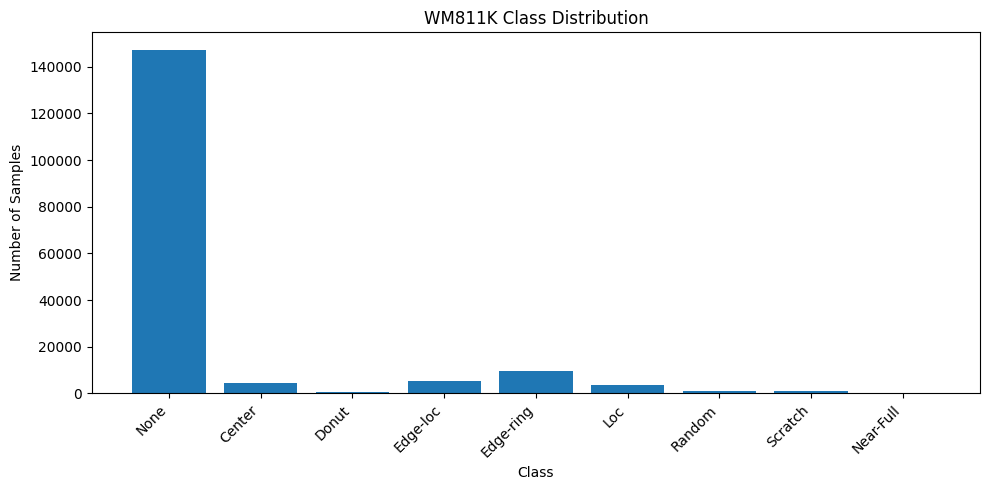

[INFO] 已輸出類別分布圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_class_distribution.png


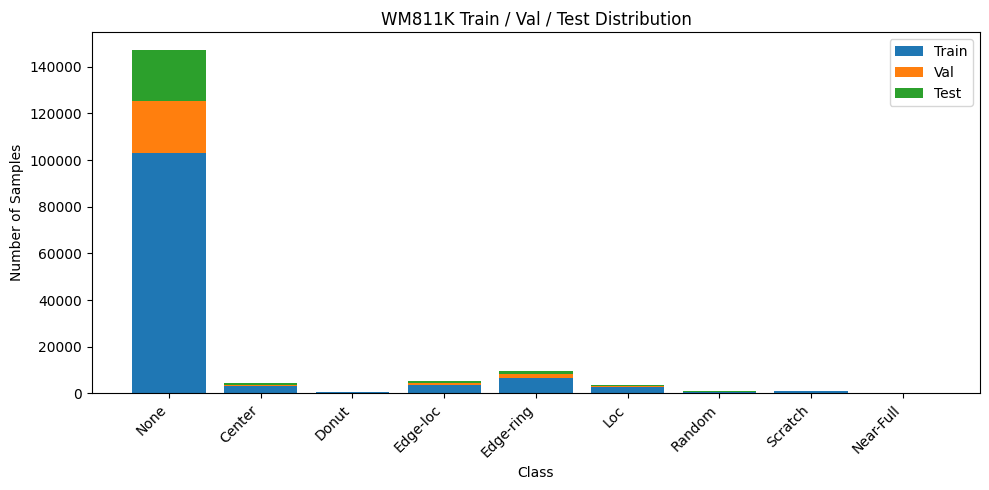

[INFO] 已輸出 Train / Val / Test 分布圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_train_val_test_distribution.png


In [ ]:
# =========================================================
# WM811K 類別樣本數統計與類別分布圖
# 用途：
# 1. 產生報告用的 WM811K 類別樣本數表
# 2. 產生 Train / Val / Test 類別分布表
# 3. 產生類別不平衡長條圖
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. 修改成你的資料集路徑
# =========================================================
DATASET_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\newdataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR   = os.path.join(DATASET_DIR, "val")
TEST_DIR  = os.path.join(DATASET_DIR, "test")

OUT_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_LIST = [
    "None",
    "Center",
    "Donut",
    "Edge-loc",
    "Edge-ring",
    "Loc",
    "Random",
    "Scratch",
    "Near-Full",
]

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp"}


# =========================================================
# 2. 統計每個資料夾中的各類別樣本數
# =========================================================
def count_class_samples(root_dir, class_list):
    counts = {}

    for class_name in class_list:
        class_dir = os.path.join(root_dir, class_name)

        if not os.path.isdir(class_dir):
            counts[class_name] = 0
            continue

        n = 0
        for filename in os.listdir(class_dir):
            ext = os.path.splitext(filename)[1].lower()
            if ext in IMG_EXTS:
                n += 1

        counts[class_name] = n

    return counts


train_counts = count_class_samples(TRAIN_DIR, CLASS_LIST)
val_counts = count_class_samples(VAL_DIR, CLASS_LIST)
test_counts = count_class_samples(TEST_DIR, CLASS_LIST)


# =========================================================
# 3. 建立 Train / Val / Test 類別樣本數表
# =========================================================
rows = []

for class_name in CLASS_LIST:
    train_n = train_counts[class_name]
    val_n = val_counts[class_name]
    test_n = test_counts[class_name]
    total_n = train_n + val_n + test_n

    rows.append({
        "類別": class_name,
        "訓練集樣本數": train_n,
        "驗證集樣本數": val_n,
        "測試集樣本數": test_n,
        "合計": total_n,
    })

df_counts = pd.DataFrame(rows)

total_all = df_counts["合計"].sum()
df_counts["比例"] = df_counts["合計"] / total_all
df_counts["比例(%)"] = (df_counts["比例"] * 100).round(2)

print("==============================")
print("WM811K 類別樣本數分布")
print("==============================")
display(df_counts)


# =========================================================
# 4. 輸出 CSV
# =========================================================
csv_path = os.path.join(OUT_DIR, "wm811k_class_distribution.csv")
df_counts.to_csv(csv_path, index=False, encoding="utf-8-sig")

print(f"[INFO] 已輸出 CSV：{csv_path}")


# =========================================================
# 5. 產生類別分布長條圖
# =========================================================
plt.figure(figsize=(10, 5))
plt.bar(df_counts["類別"], df_counts["合計"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("WM811K Class Distribution")
plt.tight_layout()

fig_path = os.path.join(OUT_DIR, "wm811k_class_distribution.png")
plt.savefig(fig_path, dpi=300)
plt.show()

print(f"[INFO] 已輸出類別分布圖：{fig_path}")


# =========================================================
# 6. 產生 Train / Val / Test 堆疊分布圖
# =========================================================
plt.figure(figsize=(10, 5))

x = range(len(CLASS_LIST))
train_values = df_counts["訓練集樣本數"]
val_values = df_counts["驗證集樣本數"]
test_values = df_counts["測試集樣本數"]

plt.bar(x, train_values, label="Train")
plt.bar(x, val_values, bottom=train_values, label="Val")
plt.bar(x, test_values, bottom=train_values + val_values, label="Test")

plt.xticks(x, CLASS_LIST, rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("WM811K Train / Val / Test Distribution")
plt.legend()
plt.tight_layout()

fig_path_split = os.path.join(OUT_DIR, "wm811k_train_val_test_distribution.png")
plt.savefig(fig_path_split, dpi=300)
plt.show()

print(f"[INFO] 已輸出 Train / Val / Test 分布圖：{fig_path_split}")


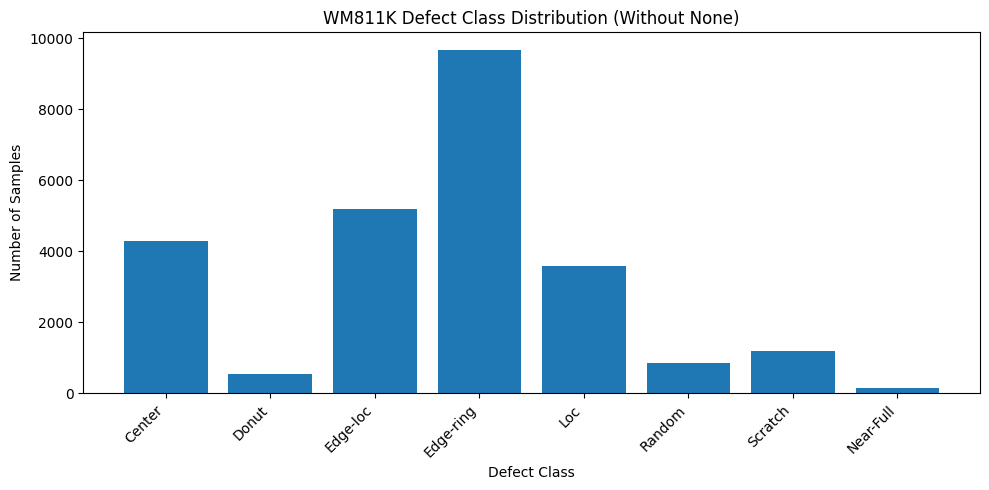

[INFO] 已輸出去掉 None 的缺陷類別分布圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_defect_class_distribution_without_none.png


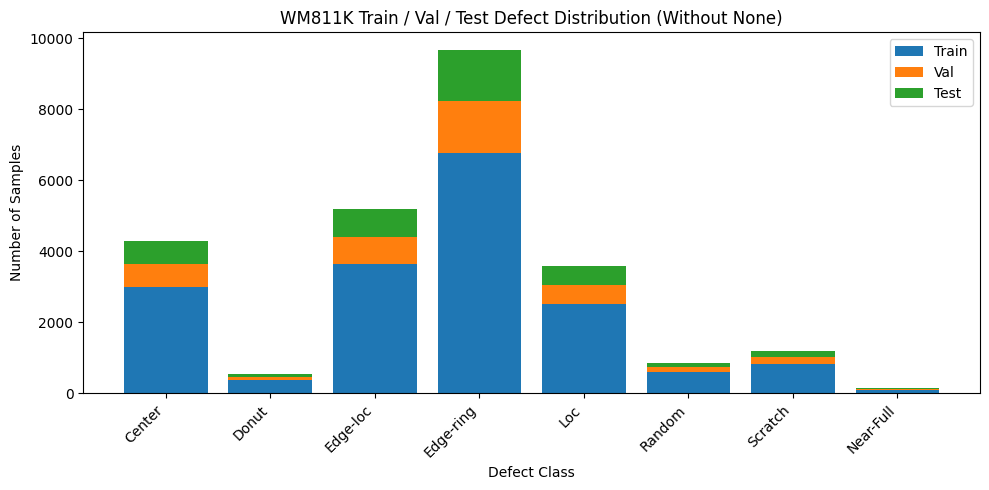

[INFO] 已輸出去掉 None 的 Train / Val / Test 缺陷分布圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_train_val_test_defect_distribution_without_none.png


In [ ]:
# =========================================================
# 7. 產生去掉 None 的缺陷類別分布圖
# =========================================================

df_defect_only = df_counts[df_counts["類別"] != "None"].copy()

plt.figure(figsize=(10, 5))
plt.bar(df_defect_only["類別"], df_defect_only["合計"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Defect Class")
plt.ylabel("Number of Samples")
plt.title("WM811K Defect Class Distribution (Without None)")
plt.tight_layout()

fig_path_defect_only = os.path.join(
    OUT_DIR,
    "wm811k_defect_class_distribution_without_none.png"
)
plt.savefig(fig_path_defect_only, dpi=300)
plt.show()

print(f"[INFO] 已輸出去掉 None 的缺陷類別分布圖：{fig_path_defect_only}")


# =========================================================
# 8. 產生去掉 None 的 Train / Val / Test 堆疊分布圖
# =========================================================

plt.figure(figsize=(10, 5))

defect_classes = df_defect_only["類別"].tolist()
x = range(len(defect_classes))

train_values = df_defect_only["訓練集樣本數"]
val_values = df_defect_only["驗證集樣本數"]
test_values = df_defect_only["測試集樣本數"]

plt.bar(x, train_values, label="Train")
plt.bar(x, val_values, bottom=train_values, label="Val")
plt.bar(x, test_values, bottom=train_values + val_values, label="Test")

plt.xticks(x, defect_classes, rotation=45, ha="right")
plt.xlabel("Defect Class")
plt.ylabel("Number of Samples")
plt.title("WM811K Train / Val / Test Defect Distribution (Without None)")
plt.legend()
plt.tight_layout()

fig_path_split_defect_only = os.path.join(
    OUT_DIR,
    "wm811k_train_val_test_defect_distribution_without_none.png"
)
plt.savefig(fig_path_split_defect_only, dpi=300)
plt.show()

print(f"[INFO] 已輸出去掉 None 的 Train / Val / Test 缺陷分布圖：{fig_path_split_defect_only}")


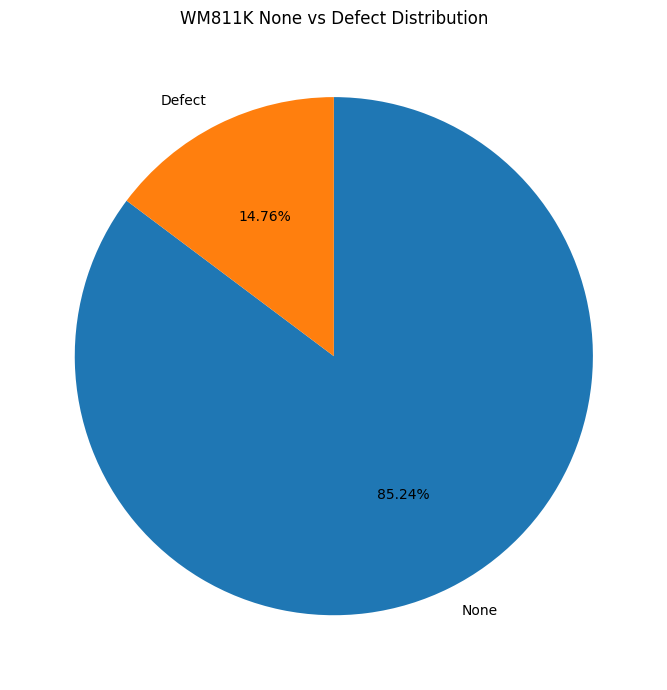

[INFO] 已輸出是否缺陷圓餅圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_none_vs_defect_pie.png


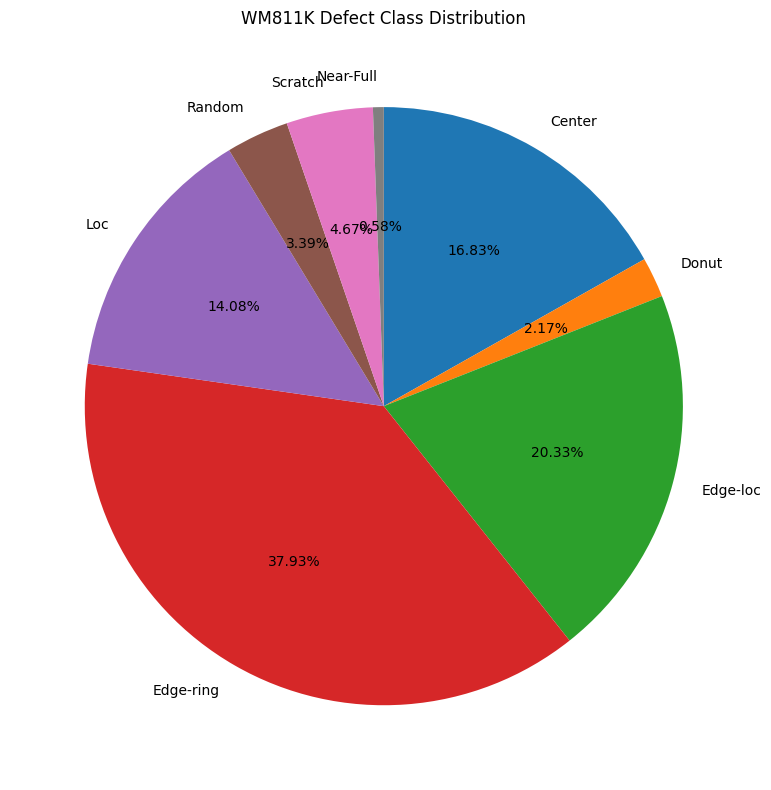

[INFO] 已輸出缺陷 8 類圓餅圖：C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis\wm811k_defect_8_classes_pie.png

========== None vs Defect ==========
None   : 147431 (85.24%)
Defect : 25519 (14.76%)
Total  : 172950

========== Defect 8 Classes ==========
Center    :   4294 (16.83%)
Donut     :    555 (2.17%)
Edge-loc  :   5189 (20.33%)
Edge-ring :   9680 (37.93%)
Loc       :   3593 (14.08%)
Random    :    866 (3.39%)
Scratch   :   1193 (4.67%)
Near-Full :    149 (0.58%)
Defect Total: 25519


In [ ]:
# =========================================================
# WM811K 圓餅圖繪製
# 1. 是否缺陷：None vs Defect
# 2. 缺陷 8 類分布：不含 None
# =========================================================

import os
import matplotlib.pyplot as plt

# =========================================================
# 1. 輸出資料夾
# =========================================================
OUT_DIR = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset_analysis"
os.makedirs(OUT_DIR, exist_ok=True)

# =========================================================
# 2. WM811K 類別總樣本數
# =========================================================
class_counts = {
    "None": 147431,
    "Center": 4294,
    "Donut": 555,
    "Edge-loc": 5189,
    "Edge-ring": 9680,
    "Loc": 3593,
    "Random": 866,
    "Scratch": 1193,
    "Near-Full": 149,
}

# =========================================================
# 3. 圓餅圖一：是否缺陷 None vs Defect
# =========================================================
none_count = class_counts["None"]
defect_count = sum(v for k, v in class_counts.items() if k != "None")

labels_binary = ["None", "Defect"]
values_binary = [none_count, defect_count]

plt.figure(figsize=(7, 7))
plt.pie(
    values_binary,
    labels=labels_binary,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False
)
plt.title("WM811K None vs Defect Distribution")
plt.tight_layout()

binary_pie_path = os.path.join(OUT_DIR, "wm811k_none_vs_defect_pie.png")
plt.savefig(binary_pie_path, dpi=300)
plt.show()

print(f"[INFO] 已輸出是否缺陷圓餅圖：{binary_pie_path}")

# =========================================================
# 4. 圓餅圖二：缺陷 8 類分布，不含 None
# =========================================================
defect_class_counts = {
    k: v for k, v in class_counts.items() if k != "None"
}

labels_defect = list(defect_class_counts.keys())
values_defect = list(defect_class_counts.values())

plt.figure(figsize=(8, 8))
plt.pie(
    values_defect,
    labels=labels_defect,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False
)
plt.title("WM811K Defect Class Distribution")
plt.tight_layout()

defect_pie_path = os.path.join(OUT_DIR, "wm811k_defect_8_classes_pie.png")
plt.savefig(defect_pie_path, dpi=300)
plt.show()

print(f"[INFO] 已輸出缺陷 8 類圓餅圖：{defect_pie_path}")

# =========================================================
# 5. 額外輸出數值確認
# =========================================================
total_count = sum(class_counts.values())

print("\n========== None vs Defect ==========")
print(f"None   : {none_count} ({none_count / total_count * 100:.2f}%)")
print(f"Defect : {defect_count} ({defect_count / total_count * 100:.2f}%)")
print(f"Total  : {total_count}")

print("\n========== Defect 8 Classes ==========")
defect_total = sum(values_defect)

for label, value in defect_class_counts.items():
    print(f"{label:10s}: {value:6d} ({value / defect_total * 100:.2f}%)")

print(f"Defect Total: {defect_total}")
